In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from joblib import dump, load

In [62]:
data22 = pd.read_csv(r"../Data/dropout_clean_2022.csv")
trimmed = pd.read_csv(r"../Data/dropout_clean_trimmed.csv")
trimmed.rename(columns={"Platform Days Logged (Total)": "Poliformat Days Logged (Total)"}, inplace=True)
data22 = data22[trimmed.columns.to_list()].drop(columns = "Entry Year")
data22.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20427 entries, 0 to 20426
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Dropout (1=Yes 0=No)            20427 non-null  int64  
 1   Performance Bucket              19262 non-null  float64
 2   Pass Rate Semester A (%)        17284 non-null  float64
 3   Pass Rate Semester B (%)        19183 non-null  float64
 4   Pass Rate Last Year (%)         14551 non-null  float64
 5   Credits Passed Normal           20427 non-null  float64
 6   Credits Passed Sem A            20427 non-null  float64
 7   Credits Passed Sem B            20427 non-null  float64
 8   Credits Enrolled Total          20427 non-null  float64
 9   Poliformat Days Logged (Total)  13891 non-null  float64
 10  Campus WiFi Days (Total)        16672 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 1.7 MB


print(trimmed.columns)

from sklearn.model_selection import train_test_split

X = data22.drop(columns="Dropout (1=Yes 0=No)")
y = data22["Dropout (1=Yes 0=No)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,          # reproducible
    stratify=y                # keeps dropout ratio equal in both splits
)

clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)
param_grid = {'max_leaf_nodes': range(2, clf.tree_.n_leaves + 1)}

clf = RandomForestClassifier()

clf.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 

In [63]:
clf = load("../Models/random_forest.joblib")

In [64]:
columns = data22.columns.drop("Dropout (1=Yes 0=No)")

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(data22[columns])
y_test = data22["Dropout (1=Yes 0=No)"]
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18933
           1       0.95      0.90      0.92      1494

    accuracy                           0.99     20427
   macro avg       0.97      0.95      0.96     20427
weighted avg       0.99      0.99      0.99     20427

[[18863    70]
 [  151  1343]]


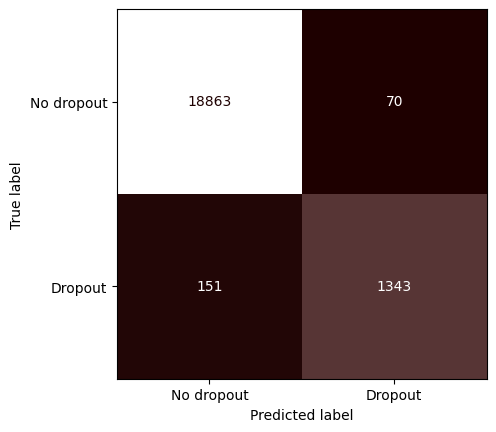

In [66]:
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import colormaps
ConfusionMatrixDisplay.from_predictions(
    data22["Dropout (1=Yes 0=No)"], y_pred,
    labels=[0, 1],
    display_labels=["No dropout", "Dropout"],
    cmap = colormaps["pink"],
    colorbar=False)


dump(clf, "../Models/random_forest.joblib")